# Section 6.4

## Example 6.4.1

We solve the IVP

$$
u'=\sin[(u+t)^2], \quad t \in [0,4], \quad u(0)=-1.
$$

In [1]:
using OrdinaryDiffEq
f(u, p, t) = sin((t + u)^2)
tspan = (0.0, 4.0)
u₀ = -1.0
ivp = ODEProblem(f, u₀, tspan)

ODEProblem with uType Float64 and tType Float64. In-place: false
Non-trivial mass matrix: false
timespan: (0.0, 4.0)
u0: -1.0

We use a `DifferentialEquations` solver to construct an accurate approximation to the exact solution.

In [2]:
u_ref = solve(ivp, Tsit5(), reltol=1e-14, abstol=1e-14);

Now we perform a convergence study of our two Runge–Kutta implementations.

In [5]:
using FNCFunctions, LinearAlgebra, PrettyTables
n = [round(Int, 2 * 10^k) for k in 0:0.5:3]
err = zeros(length(n), 2)
for (k, n) in enumerate(n)
    t, u = FNC.ie2(ivp, n)
    err[k, 1] = norm(u_ref.(t) - u, Inf)
    t, u = FNC.rk4(ivp, n)
    err[k, 2] = norm(u_ref.(t) - u, Inf)
end
pretty_table((n=n, err2=err[:, 1], err4=err[:, 2]); 
    column_labels=["n", "IE2 error", "RK4 error"], backend=:html)

n,IE2 error,RK4 error
2,1.76903,0.820651
6,0.512684,0.791925
20,0.0240594,0.00081269
63,0.00225327,8.06216e-6
200,0.000222419,7.60655e-8
632,2.22528e-5,7.513e-10
2000,2.22177e-6,7.45182e-12


The amount of computational work at each time step is assumed to be proportional to the number of stages. Let's compare on an apples-to-apples basis by using the number of $f$-evaluations on the horizontal axis.

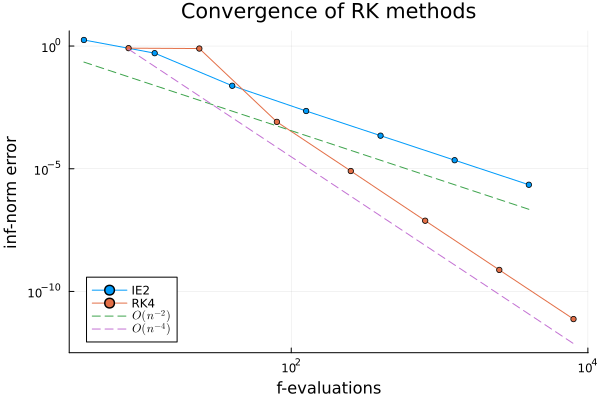

In [6]:
using Plots, LaTeXStrings
plot([2n 4n], err;
    m=3, label=["IE2" "RK4"], legend=:bottomleft,
    xaxis=(:log10, "f-evaluations"),  yaxis=(:log10, "inf-norm error"),
    title="Convergence of RK methods")

plot!(2n, 0.1 * err[end,1] * (n / n[end]) .^ (-2), l=:dash, label=L"O(n^{-2})")
plot!(4n, 0.1 * err[end,2] * (n / n[end]) .^ (-4), l=:dash, label=L"O(n^{-4})")

The fourth-order variant is more efficient in this problem over a wide range of accuracy.